In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#   kernelspec:
#     display_name: Python 3
#     language: python
#     name: python3
# ---

# 4절 자명해 시연 — 상수 출력 하나로 loss를 0으로 만들기

카드 질문: **4절의 자명해 시연에서 원-핫 붕괴를 어떻게 흉내 냈고 loss는 얼마였는가?**

답의 핵심은 두 줄이다.

```python
const = torch.zeros(B, out_dim); const[:, 2] = 50.0   # 모든 샘플이 2번 차원에 로짓 50
s_out = torch.cat([const, const]);  t_out = s_out.clone()   # 두 crop에 똑같이
# → loss = 0.0000
```

학습은 없다. "네트워크가 입력을 아예 안 보고 항상 같은 로짓을 뱉는다"고 **가정만** 하고
`DINOLoss`를 한 번 호출한다. 그런데 점수가 만점(0)이다.

이 스크립트는 노트북 4절을 그대로 재현한 뒤 네 방향으로 늘린다.

1. 세 시나리오 재현 — 원-핫 붕괴 0.0, 균등 붕괴 $\log 8$, 건강한 원-핫 0.0
2. **로짓 크기 $c$ 스윕** — 왜 하필 50인가? 언제부터 float32에서 진짜 0이 되나
3. **`use_center=True`** — centering을 켜면 이 치트가 어떻게 무너지는가
4. **loss는 붕괴를 못 잡는다**의 정량화 — 보조 지표 표

의존성: `torch`, `plotly`, `kaleido`.

In [2]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import plotly.graph_objects as go
from plotly.subplots import make_subplots

torch.manual_seed(0)
torch.set_printoptions(precision=3, sci_mode=False)


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__)

torch 2.4.0+cu121


## 0. `MiniDINOLoss` — 노트북 3절과 동일 (자립 실행용 재정의)

원본 `main_dino.py`의 `DINOLoss`에서 `dist.all_reduce`와 teacher temp warmup만 뺀 것이다.
붕괴 방지 두 장치가 `forward` 안의 한 줄에 모여 있다.

$$q = \mathrm{softmax}\!\left(\frac{z^{t} - \mathrm{center}}{\tau_t}\right),\qquad
  p = \mathrm{softmax}\!\left(\frac{z^{s}}{\tau_s}\right),\qquad
  \mathcal{L} = -\sum_i q_i \log p_i$$

기본값은 $\tau_t = 0.04$ (sharpening), $\tau_s = 0.1$.

In [3]:
class MiniDINOLoss(nn.Module):
    def __init__(self, out_dim, ncrops, teacher_temp, student_temp=0.1,
                 center_momentum=0.9, use_center=True):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.ncrops = ncrops
        self.use_center = use_center
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_output, teacher_output):
        student_out = (student_output / self.student_temp).chunk(self.ncrops)

        center = self.center if self.use_center else 0.0
        teacher_out = F.softmax((teacher_output - center) / self.teacher_temp, dim=-1)
        teacher_out = teacher_out.detach().chunk(2)

        total_loss, n_terms = 0.0, 0
        for iq, q in enumerate(teacher_out):
            for v in range(len(student_out)):
                if v == iq:
                    continue
                loss = torch.sum(-q * F.log_softmax(student_out[v], dim=-1), dim=-1)
                total_loss += loss.mean()
                n_terms += 1
        total_loss /= n_terms
        self.update_center(teacher_output)
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_output):
        batch_center = teacher_output.mean(dim=0, keepdim=True)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)


def entropy(p):
    return -(p * p.clamp_min(1e-12).log()).sum(-1)

## 1. 노트북 4절 재현 — 세 가지 상수 출력

`B=16`, `out_dim=8`. crop은 global 2개뿐이므로 `ncrops=2`, 그리고 centering은 일단 끈다.

In [4]:
B, out_dim = 16, 8
loss_fn = MiniDINOLoss(out_dim, ncrops=2, teacher_temp=0.04, use_center=False)

# (1) 원-핫 붕괴 — 카드가 묻는 바로 그 코드
const = torch.zeros(B, out_dim)
const[:, 2] = 50.0
s_out = torch.cat([const, const])          # crop 2개, 전부 같은 출력
t_out = s_out.clone()
l_onehot = loss_fn(s_out, t_out).item()
print(f"one-hot collapse : loss = {l_onehot:.4f}   ← 0. 완벽한 점수")

# (2) 균등 붕괴 — 전부 0 로짓
zeros = torch.zeros(2 * B, out_dim)
l_uniform = loss_fn(zeros, zeros).item()
print(f"uniform collapse : loss = {l_uniform:.4f}   ← log 8 = {math.log(8):.4f}, KL은 0")

# (3) 건강한 경우 — 입력마다 다른 원-핫
healthy = F.one_hot(torch.arange(B) % out_dim, out_dim).float() * 50.0
h_out = torch.cat([healthy, healthy])
l_healthy = loss_fn(h_out, h_out).item()
print(f"healthy one-hot  : loss = {l_healthy:.4f}   ← 이것도 0")

print(f"\n노트북 수치와 일치? {l_onehot == 0.0 and abs(l_uniform - math.log(8)) < 1e-4 and l_healthy == 0.0}")

one-hot collapse : loss = 0.0000   ← 0. 완벽한 점수
uniform collapse : loss = 2.0794   ← log 8 = 2.0794, KL은 0
healthy one-hot  : loss = 0.0000   ← 이것도 0

노트북 수치와 일치? True


`const[:, 2] = 50.0` 한 줄이 "붕괴한 네트워크"의 전부다. 배치의 **16개 샘플이 전부 같은 행**이고,
두 crop(`torch.cat([const, const])`)에도 **똑같은** 값이 들어간다.
teacher와 student가 같은 값을 보므로 $q$도 $p$도 2번 차원에 몰린 원-핫이 되고,
$H(q,p) = h(q) + D_{KL}(q\|p) = 0 + 0 = 0$.

(1)과 (3)의 loss가 **똑같이 0**이라는 게 4절의 진짜 메시지다.
loss는 "입력이 출력을 바꾸는가"를 아예 보지 않는다.

## 2. 왜 하필 50인가 — 로짓 크기 스윕

`const[:, 2] = c` 의 $c$를 0부터 50까지 움직여 보자. 결정적인 건 **온도로 나뉜다**는 점이다.

$$\text{teacher 실효 로짓} = \frac{c}{\tau_t} = \frac{c}{0.04} = 25c,
  \qquad \text{student 실효 로짓} = \frac{c}{\tau_s} = 10c$$

즉 $c=50$은 teacher에게 **1250**짜리 로짓이다. $e^{1250}$ 대 $e^0$의 싸움이라 $q$는 완벽한 원-핫이다.
손으로 쓰면 loss는

$$\mathcal{L}(c) = \underbrace{q_2\log\!\left(1 + 7e^{-10c}\right)}_{\text{정답 차원 항}}
  \;+\; \underbrace{7\,q_{\neq}\left(10c + \log(1+7e^{-10c})\right)}_{\text{나머지 7개}},
  \qquad q_2 = \frac{e^{25c}}{e^{25c}+7}$$

$c=0$이면 $\log 8$, $c\to\infty$면 $0$. 지수로 죽으므로 **아주 빨리** 0에 닿는다.

In [5]:
def const_loss(c, temp_t=0.04, temp_s=0.1, B=16, out_dim=8):
    fn = MiniDINOLoss(out_dim, ncrops=2, teacher_temp=temp_t, student_temp=temp_s, use_center=False)
    x = torch.zeros(B, out_dim)
    x[:, 2] = c
    xx = torch.cat([x, x])
    return fn(xx, xx.clone()).item()


cs = torch.cat([torch.linspace(0, 6, 601), torch.linspace(6.1, 50, 440)])
losses = torch.tensor([const_loss(c.item()) for c in cs])

first_zero = cs[(losses == 0.0).nonzero()[0, 0]].item()
first_1em6 = cs[(losses < 1e-6).nonzero()[0, 0]].item()
first_1em3 = cs[(losses < 1e-3).nonzero()[0, 0]].item()
print(f"loss < 1e-3  : c >= {first_1em3:.3f}   (실효 student 로짓 {10*first_1em3:.1f})")
print(f"loss < 1e-6  : c >= {first_1em6:.3f}   (실효 student 로짓 {10*first_1em6:.1f})")
print(f"loss == 0.0  : c >= {first_zero:.3f}   (실효 student 로짓 {10*first_zero:.1f})  ← float32에서 '진짜' 0")
print(f"c=50 은 여기서 {50/first_zero:.0f}배 여유.  teacher 실효 로짓 = 50/0.04 = {50/0.04:.0f}")

for c in [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 4.2, 50.0]:
    print(f"  c={c:5.2f}  10c={10*c:6.1f}  25c={25*c:7.1f}  loss={const_loss(c):.3e}")

loss < 1e-3  : c >= 0.890   (실효 student 로짓 8.9)
loss < 1e-6  : c >= 1.580   (실효 student 로짓 15.8)
loss == 0.0  : c >= 4.160   (실효 student 로짓 41.6)  ← float32에서 '진짜' 0
c=50 은 여기서 12배 여유.  teacher 실효 로짓 = 50/0.04 = 1250
  c= 0.00  10c=   0.0  25c=    0.0  loss=2.079e+00
  c= 0.05  10c=   0.5  25c=    1.2  loss=1.991e+00
  c= 0.10  10c=   1.0  25c=    2.5  loss=1.639e+00
  c= 0.20  10c=   2.0  25c=    5.0  loss=7.566e-01
  c= 0.50  10c=   5.0  25c=   12.5  loss=4.622e-02
  c= 1.00  10c=  10.0  25c=   25.0  loss=3.178e-04
  c= 1.50  10c=  15.0  25c=   37.5  loss=2.146e-06
  c= 2.00  10c=  20.0  25c=   50.0  loss=2.700e-20
  c= 3.00  10c=  30.0  25c=   75.0  loss=5.625e-31
  c= 4.00  10c=  40.0  25c=  100.0  loss=1.059e-41
  c= 4.20  10c=  42.0  25c=  105.0  loss=0.000e+00
  c=50.00  10c= 500.0  25c= 1250.0  loss=0.000e+00


읽는 법 — 0으로 가는 길이 **두 단계**다.

- $c \approx 0.89$면 벌써 loss $< 10^{-3}$, $c \approx 1.58$이면 $< 10^{-6}$.
  온도가 로짓을 10~25배로 뻥튀기하니 $c$가 1 근처만 돼도 사실상 붕괴다.
- **1단계 ($c \approx 2$):** 정답 차원 항 $\log(1+7e^{-10c})$가 죽는다.
  `log_softmax`는 $z - \mathrm{logsumexp}(z)$인데 $10c=20$이면 $7e^{-20}\approx1.4\times10^{-8}$이
  float32 유효자리 밖이라 `log_softmax`의 정답 성분이 정확히 `0.0`이 된다.
  그 뒤 남는 건 나머지 7차원 항 $7e^{-25c}\cdot 10c$ 뿐이라 loss가 $2.7\times10^{-20}$으로 뚝 떨어진다.
- **2단계 ($c \approx 4.16$):** 그 잔여항의 $e^{-25c}$가 float32 최소 비정규수($1.4\times10^{-45}$) 아래로
  **underflow** 한다. $25c \approx 104$ 지점이고, 여기서부터 loss는 비트 단위로 정확히 `0.0`이다.
- 노트북이 쓴 $c=50$은 그 문턱의 **약 12배**. "확실하게 붕괴한 상태"를 넉넉히 잡은 값이지
  50이라는 숫자 자체에 의미가 있는 건 아니다. $c=5$로 바꿔도 loss는 똑같이 정확히 0이다.

## 3. `use_center=True` — centering이 이 치트에 벌점을 매긴다

위 시연은 `use_center=False`였다. 이제 **똑같은 상수 출력**에 centering을 켜고
`forward`를 여러 번 반복 호출한다. `update_center`가 매번

$$\mathrm{center} \leftarrow 0.9\,\mathrm{center} + 0.1\,\overline{z^{t}}$$

를 돌리는데, 모든 행이 같으므로 배치 평균 $\overline{z^t}$은 상수 행 그 자체다. 따라서 $t$ 스텝 뒤

$$\mathrm{center}_t = (1 - 0.9^{t})\cdot \mathrm{const},\qquad
  z^{t} - \mathrm{center}_t = 0.9^{t}\cdot \mathrm{const}$$

**center가 상수 출력을 지수적으로 상쇄한다.** teacher의 실효 로짓은 $1250 \cdot 0.9^{t}$로 줄어들고,
$t \approx 68$쯤에 $O(1)$이 되면서 $q$가 균등분포로 무너진다.

두 갈래를 같이 그린다.

- **teacher만 centering** (실제 `DINOLoss`): student는 여전히 뾰족한 원-핫이라
  $q$가 평평해지는 순간 $-\sum q\log p$가 **폭발**한다.
- **student도 같이 평평해지는 경우**: 모델이 벌점을 피해 도망가면 $q$와 $p$가 함께 균등해져 loss $\to \log 8$.
  이게 "centering만 켜면 균등 붕괴로 간다"의 정체다.

In [6]:
STEPS = 140

# (a) 실제 DINOLoss 경로 — teacher에만 center 적용
fn_c = MiniDINOLoss(out_dim, ncrops=2, teacher_temp=0.04, use_center=True)
const2 = torch.zeros(B, out_dim)
const2[:, 2] = 50.0
xx = torch.cat([const2, const2])

steps, loss_teacher_only, eff_logit, h_q = [], [], [], []
for t in range(STEPS):
    eff = (const2 - fn_c.center)[0, 2].item() / 0.04     # 이번 스텝의 teacher 실효 로짓
    q = F.softmax((const2 - fn_c.center) / 0.04, -1)
    l = fn_c(xx, xx.clone()).item()                      # forward 끝에서 update_center 호출됨
    steps.append(t); loss_teacher_only.append(l)
    eff_logit.append(eff); h_q.append(entropy(q).mean().item())

# (b) student도 함께 상쇄되는 가상 경로 — 모델이 centering을 따라 평평해진 경우
fn_b = MiniDINOLoss(out_dim, ncrops=2, teacher_temp=0.04, use_center=True)
loss_both = []
for t in range(STEPS):
    centered = const2 - fn_b.center
    s = torch.cat([centered, centered])
    loss_both.append(fn_b(s, torch.cat([const2, const2])).item())

for t in [0, 20, 40, 50, 60, 68, 80, 100, 139]:
    print(f"step {t:4d}  teacher 실효로짓 {eff_logit[t]:9.2f}  h(q) {h_q[t]:.4f}   "
          f"loss(teacher만 center) {loss_teacher_only[t]:9.3f}   loss(student도) {loss_both[t]:7.4f}")

print(f"\nteacher만 center: 마지막 loss = {loss_teacher_only[-1]:.3f}"
      f"   (이론값 (1-1/8)*50/0.1 = {(7/8)*50/0.1:.3f})")
print(f"student도 함께  : 마지막 loss = {loss_both[-1]:.4f}   (log 8 = {math.log(8):.4f})")

step    0  teacher 실효로짓   1250.00  h(q) 0.0000   loss(teacher만 center)     0.000   loss(student도)  0.0000
step   20  teacher 실효로짓    151.97  h(q) 0.0000   loss(teacher만 center)     0.000   loss(student도)  0.0000
step   40  teacher 실효로짓     18.48  h(q) 0.0000   loss(teacher만 center)     0.000   loss(student도)  0.0043
step   50  teacher 실효로짓      6.44  h(q) 0.0821   loss(teacher만 center)     5.512   loss(student도)  0.4550
step   60  teacher 실효로짓      2.25  h(q) 1.5098   loss(teacher만 center)   212.710   loss(student도)  1.7304
step   68  teacher 실효로짓      0.97  h(q) 2.0008   loss(teacher만 center)   363.425   loss(student도)  2.0311
step   80  teacher 실효로짓      0.27  h(q) 2.0748   loss(teacher만 center)   420.954   loss(student도)  2.0765
step  100  teacher 실효로짓      0.03  h(q) 2.0794   loss(teacher만 center)   435.646   loss(student도)  2.0794
step  139  teacher 실효로짓      0.00  h(q) 2.0794   loss(teacher만 center)   437.453   loss(student도)  2.0794

teacher만 center: 마지막 loss = 437.453   (이론값 (1

**이 셀이 4절의 반쪽을 채운다.** `use_center=False`에서 만점(0)이던 자명해가,
centering을 켜자 40여 스텝 버티다가 무너진다 (step 40에 loss 0.000 → step 50에 5.5 → step 100에 435.6).

- center가 상수 출력을 **정확히** 따라잡아 $z^t - \mathrm{center} \to 0$, 즉 $q \to$ 균등.
- 그 순간 student는 아직 2번 차원만 확신하고 있으므로 $-\sum q \log p$가 $437.5$까지 치솟는다.
  ($p_{i\neq 2}$의 로그가 $-50/0.1 = -500$이고, 균등 $q$가 그중 $7/8$을 집어 든다.)
- 그래서 gradient는 "그 뾰족함을 버려라"라고 민다. 버리고 나면 도착지가 $\log 8 = 2.079$ — **균등 붕괴**.

즉 centering은 원-핫 붕괴를 **금지**하지만, 혼자서는 반대쪽 붕괴로 밀어낸다.
그래서 sharpening($\tau_t=0.04$)이 짝으로 필요하다. 노트북 6절 표의 내용이다.

곁가지 확인: 왜 하필 40~70스텝인가? 실효 로짓이 $1250\cdot 0.9^{t}$이므로
$1250\cdot 0.9^{t} = 1$ 이 되는 지점이 $t = \log 1250 / \log(1/0.9) \approx 67.7$ —
표에서 step 68의 실효 로짓이 0.97로 딱 맞는다.
그 앞 step 40(실효 로짓 18.5)까지는 $q$가 아직 float32 기준 완전한 원-핫이라 loss가 0을 유지한다.
2절에서 본 "$25c \approx 40$ 위면 사실상 원-핫"이라는 문턱과 같은 이야기다.

## 4. "loss는 붕괴를 못 잡는다"를 숫자로

붕괴 출력과 건강한 출력의 loss는 **같다**(둘 다 0). 구분하려면 다른 걸 봐야 한다.
노트북 5절이 쓰는 세 지표를 teacher 분포 $q$ 위에서 계산한다.

| 지표 | 정의 | 뜻 |
|---|---|---|
| `h_each` | $\frac{1}{B}\sum_b h(q_b)$ | 샘플 하나하나가 확신하는가 |
| `h_mean` | $h\!\left(\frac{1}{B}\sum_b q_b\right)$ | 배치 전체가 차원을 골고루 쓰는가 |
| `top_share` | 가장 많이 뽑힌 argmax 차원의 비율 | 한 차원이 판을 덮는가 |

`h_each` 낮음 + `h_mean` 높음 = 건강. 둘 다 낮음 = 원-핫 붕괴. 둘 다 높음 = 균등 붕괴.

In [7]:
@torch.no_grad()
def metrics(logits, teacher_temp=0.04):
    q = F.softmax(logits / teacher_temp, -1)
    codes = q.argmax(-1)
    top_share = codes.bincount(minlength=q.shape[-1]).max().item() / len(codes)
    he, hm = entropy(q).mean().item(), entropy(q.mean(0)).item()
    return q, abs(he) if abs(he) < 1e-9 else he, abs(hm) if abs(hm) < 1e-9 else hm, top_share


scenarios = [
    ("원-핫 붕괴 const[:,2]=50", const, l_onehot),
    ("균등 붕괴  zeros",          torch.zeros(B, out_dim), l_uniform),
    ("건강한 원-핫 (샘플별로 다름)", healthy, l_healthy),
]

print(f"{'시나리오':30s} {'loss':>8s} {'h_each':>8s} {'h_mean':>8s} {'top_share':>10s}")
print("-" * 68)
qs = {}
for name, logits, lv in scenarios:
    q, he, hm, ts = metrics(logits)
    qs[name] = q
    print(f"{name:30s} {lv:8.4f} {he:8.4f} {hm:8.4f} {ts:10.3f}")
print(f"\nlog 8 = {math.log(8):.4f},  1/8 = {1/8:.3f}")

시나리오                               loss   h_each   h_mean  top_share
--------------------------------------------------------------------
원-핫 붕괴 const[:,2]=50             0.0000   0.0000   0.0000      1.000
균등 붕괴  zeros                     2.0794   2.0794   2.0794      1.000
건강한 원-핫 (샘플별로 다름)                0.0000   0.0000   2.0794      0.125

log 8 = 2.0794,  1/8 = 0.125


**결론 한 줄: `loss` 열은 1행과 3행이 같고(0.0000), `h_mean`/`top_share` 열은 완전히 다르다.**

- 원-핫 붕괴: `h_mean = 0`, `top_share = 1.0` — 16개 샘플 전부 2번 차원.
- 건강: `h_mean = log 8 = 2.079`(8개 차원을 골고루), `top_share = 1/8 = 0.125`.
- `h_each`는 1행과 3행 모두 0이다. **이 지표 하나만으로는 구분 못 한다** —
  노트북이 "`h_each`와 `h_mean`은 짝으로 봐야 한다"고 한 이유가 이것이다.

주의: 균등 붕괴 행의 `top_share = 1.0`은 지표의 함정이다. 모든 확률이 정확히 $1/8$로 동률이라
`argmax`가 항상 0번을 돌려주기 때문이지, 한 차원이 지배해서가 아니다.
실전에서는 로짓에 노이즈가 있어 이 값이 $1/K$ 근처로 흩어진다. 균등 붕괴는 `h_each`로 잡아야 한다.

그래서 실전에서는 `eval_knn.py`를 따로 돌리거나 teacher 출력의 `h_each`/`h_mean`/`top_share`를
로깅한다. loss 곡선만 보고 있으면 붕괴가 진행 중인 걸 모른다.

## 5. 시각화

- (a) 로짓 크기 $c$ vs loss — 어디서 0에 닿는가
- (b) centering 스텝 vs loss — 자명해가 무너지는 과정
- (c)(d) 붕괴 / 건강 두 상태의 teacher 분포 히트맵 (배치 × 차원)

히트맵이 가장 직관적이다: 붕괴는 **모든 행이 같은 열**에 몰려 있고, 건강은 대각선으로 흩어진다.
loss는 둘 다 0이다.

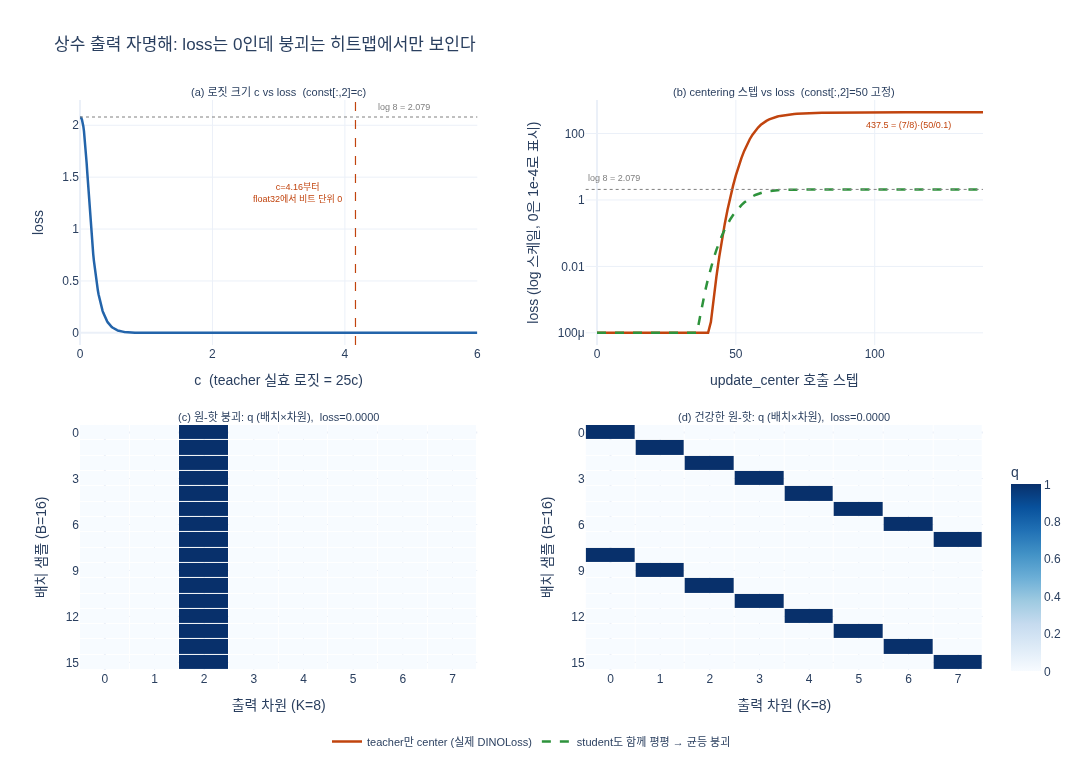

saved expy.png


In [8]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "(a) 로짓 크기 c vs loss  (const[:,2]=c)",
        "(b) centering 스텝 vs loss  (const[:,2]=50 고정)",
        "(c) 원-핫 붕괴: q (배치×차원),  loss=0.0000",
        "(d) 건강한 원-핫: q (배치×차원),  loss=0.0000",
    ),
    specs=[[{}, {}], [{"type": "heatmap"}, {"type": "heatmap"}]],
    vertical_spacing=0.14, horizontal_spacing=0.12,
)

# (a)
mask = cs <= 6.0
fig.add_trace(go.Scatter(x=cs[mask], y=losses[mask], mode="lines", name="loss(c)",
                         showlegend=False, line=dict(color="#2364AA", width=2.5)), row=1, col=1)
fig.add_hline(y=math.log(8), line=dict(dash="dot", color="gray", width=1), row=1, col=1)
fig.add_annotation(x=4.9, y=math.log(8), text="log 8 = 2.079", showarrow=False,
                   yshift=10, font=dict(size=9, color="gray"), row=1, col=1)
fig.add_vline(x=first_zero, line=dict(dash="dash", color="#C1440E", width=1.2), row=1, col=1)
fig.add_annotation(x=first_zero, y=1.35, text=f"c={first_zero:.2f}부터<br>float32에서 비트 단위 0",
                   showarrow=False, xshift=-58, font=dict(size=9, color="#C1440E"), row=1, col=1)
fig.update_xaxes(title_text="c  (teacher 실효 로짓 = 25c)", row=1, col=1)
fig.update_yaxes(title_text="loss", row=1, col=1)

# (b)
FLOOR = 1e-4
cl = lambda v: [max(x, FLOOR) for x in v]
fig.add_trace(go.Scatter(x=steps, y=cl(loss_teacher_only), mode="lines", name="teacher만 center (실제 DINOLoss)",
                         line=dict(color="#C1440E", width=2.5)), row=1, col=2)
fig.add_trace(go.Scatter(x=steps, y=cl(loss_both), mode="lines", name="student도 함께 평평 → 균등 붕괴",
                         line=dict(color="#2E933C", width=2.5, dash="dash")), row=1, col=2)
fig.add_hline(y=math.log(8), line=dict(dash="dot", color="gray", width=1), row=1, col=2)
fig.add_annotation(x=6, y=math.log10(math.log(8)), text="log 8 = 2.079", showarrow=False, yshift=11,
                   font=dict(size=9, color="gray"), row=1, col=2)
fig.add_annotation(x=112, y=math.log10(437.5), text="437.5 = (7/8)·(50/0.1)", showarrow=False, yshift=-13,
                   font=dict(size=9, color="#C1440E"), row=1, col=2)
fig.update_xaxes(title_text="update_center 호출 스텝", row=1, col=2)
fig.update_yaxes(title_text="loss (log 스케일, 0은 1e-4로 표시)", type="log", row=1, col=2)

# (c)(d)
q_col = qs["원-핫 붕괴 const[:,2]=50"]
q_hea = qs["건강한 원-핫 (샘플별로 다름)"]
for col, q in [(1, q_col), (2, q_hea)]:
    fig.add_trace(go.Heatmap(z=q.numpy(), coloraxis="coloraxis",
                             xgap=1, ygap=1), row=2, col=col)
    fig.update_xaxes(title_text="출력 차원 (K=8)", dtick=1, row=2, col=col)
    fig.update_yaxes(title_text="배치 샘플 (B=16)", autorange="reversed", dtick=3, row=2, col=col)

fig.update_layout(
    coloraxis=dict(colorscale="Blues", cmin=0, cmax=1, colorbar=dict(title="q", len=0.4, y=0.18)),
    height=780, width=1080, template="plotly_white",
    title_text="상수 출력 자명해: loss는 0인데 붕괴는 히트맵에서만 보인다",
    legend=dict(orientation="h", yanchor="top", y=-0.10, xanchor="center", x=0.5, font=dict(size=11)),
    margin=dict(t=100, b=110),
)
fig.update_annotations(font_size=11, selector=dict(xref="paper"))

_show(fig)
fig.write_image("/home/sungwoo/projects/swcho/dino/fm/entropy/.fm/hints/4f75fbe4-9068-459c-99ea-227bfb3532b0/expy.png", scale=2)
print("saved expy.png")

## 정리

| 물음 | 답 |
|---|---|
| 원-핫 붕괴를 어떻게 흉내 냈나 | `const = torch.zeros(B, out_dim); const[:, 2] = 50.0` — 모든 샘플이 2번 차원에 로짓 50인 **상수** 출력 |
| 어디에 넣었나 | `s_out = torch.cat([const, const])`, `t_out = s_out.clone()` — 두 crop과 student/teacher 모두 같은 값 |
| loss는 | **0.0000**. 완벽한 점수 |
| 왜 0인가 | $q$도 $p$도 같은 원-핫 → $h(q)=0$, $D_{KL}(q\|p)=0$ |
| 왜 50인가 | $\tau_t=0.04$로 나뉘어 실효 로짓 $25c=1250$. float32에서 loss가 비트 단위로 0이 되는 문턱은 $c\approx4.16$이니 12배 여유 |
| 이게 왜 문제인가 | 입력마다 다른 원-핫을 내는 **건강한** 경우도 loss가 똑같이 0. loss로는 둘을 구분 못 한다 |
| 무엇이 막나 | `use_center=True`. center가 상수 출력을 지수적으로 상쇄해 100스텝 안에 loss를 0 → 437.5로 밀어올린다 |